## Description

In this competition, participants will work with four datasets: training, validation, test, and comp_test. The training dataset contains labeled data that competitors will use to train their models. The validation dataset allows them to fine-tune their models and assess performance during development. The test dataset provides an additional benchmark to estimate how well their models generalize to unseen data. However, the comp_test dataset is different—it consists of unlabeled data for which participants must generate predictions. Their final task is to submit predictions for this dataset, which will be evaluated against hidden ground-truth labels to determine the competition rankings.

In [1]:
#Import deep learning libraries

import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from PIL import Image
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
import os

# **Step 1: Competition Data Curation and Preprocessing** 

## Image Preprocessing Pipeline

The transformation pipeline is designed to preprocess images before feeding them into a machine learning model. The steps involved are:

1. **Convert to Grayscale**:  
   `transforms.Grayscale(num_output_channels=1)` ensures all images have a single channel, simplifying processing for models that do not require color information.

2. **Resize to a Fixed Dimension**:  
   `transforms.Resize((150, 150))` resizes all images to a standard size of **150x150 pixels**, ensuring consistency across the dataset.

3. **Convert to Tensor**:  
   `transforms.ToTensor()` converts images into **PyTorch tensors**, normalizing pixel values to the `[0,1]` range.

4. **Normalize Pixel Values**:  
   `transforms.Normalize(mean=[0.5], std=[0.5])` standardizes pixel values to have a **zero mean** and a range approximately from `[-1,1]`. This helps stabilize training and improve model performance.

This preprocessing ensures uniformity across the dataset and enhances the model’s ability to learn meaningful features.

In [2]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert images to grayscale
    transforms.Resize((150, 150)),                # Resize images to 150x150
    transforms.ToTensor(),                        # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.5], std=[0.5])   # Normalize pixel values
])

## Training Dataset Preparation

1. **Define the Training Dataset Path**:  
   The dataset is stored in the directory `/kaggle/input/intel-image-classification/seg_train/seg_train`, which contains images organized into subfolders representing different classes.

2. **Load the Dataset Using `ImageFolder`**:  
   `datasets.ImageFolder(root=train_path, transform=transform)` automatically assigns labels based on subfolder names and applies the predefined transformations.

3. **Define the Batch Size**:  
   A `batch_size` of `32` is set, meaning the model will process 32 images at a time during training.

4. **Create the DataLoader**:  
   `DataLoader(train_dataset, batch_size=batch_size, shuffle=True)` creates an iterable that loads data in mini-batches. The `shuffle=True` ensures that the dataset is randomly shuffled at each epoch, improving generalization and preventing overfitting.

This setup enables efficient data loading, ensuring that images are properly processed and fed into the model during training.

In [3]:
import os

print(os.listdir("/kaggle/input/datasets"))
print(os.listdir("/kaggle/input/datasets/puneet6060"))
print(os.listdir("/kaggle/input/datasets/puneet6060/intel-image-classification"))

['puneet6060']
['intel-image-classification']
['seg_train', 'seg_pred', 'seg_test']


In [4]:
#Creación del csv
import os
import pandas as pd

base_path = "/kaggle/input/datasets/puneet6060/intel-image-classification"

def build_csv(split):

    rows = []
    split_path = os.path.join(base_path, split, split)

    classes = sorted(os.listdir(split_path))
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

    for label in classes:

        label_path = os.path.join(split_path, label)

        if not os.path.isdir(label_path):
            continue

        for img in os.listdir(label_path):

            if img.lower().endswith((".jpg", ".png", ".jpeg")):

                rows.append({
                    "file_path": os.path.join(label_path, img),
                    "label": class_to_idx[label]
                })

    return pd.DataFrame(rows), class_to_idx


df_train, class_map_train = build_csv("seg_train")
df_test, class_map_test = build_csv("seg_test")

df_train.to_csv("/kaggle/working/train.csv", index=False)
df_test.to_csv("/kaggle/working/test.csv", index=False)

print(df_train.head())
print("Total images:", len(df_train))
print("Class map:", class_map_train)

                                           file_path  label
0  /kaggle/input/datasets/puneet6060/intel-image-...      0
1  /kaggle/input/datasets/puneet6060/intel-image-...      0
2  /kaggle/input/datasets/puneet6060/intel-image-...      0
3  /kaggle/input/datasets/puneet6060/intel-image-...      0
4  /kaggle/input/datasets/puneet6060/intel-image-...      0
Total images: 14034
Class map: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [5]:
#Creación del dataloader
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=True):

        df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

        # based on DataFrame columns
        self.img_names = df["file_path"]
        self.labels = df["label"]

    def __getitem__(self, index):
        img = Image.open(os.path.join(self.img_dir, self.img_names[index]))

        if self.transform is not None:
            img = self.transform(img)

        label = self.labels[index]
        return img, label

    def __len__(self):
        return self.labels.shape[0]

In [6]:
from torch.utils.data import DataLoader

train_dataset = MyDataset(
    csv_path="/kaggle/working/train.csv",
    img_dir="/kaggle/working/",
    transform=transform,
)

test_dataset = MyDataset(
    csv_path="/kaggle/working/test.csv",
    img_dir="/kaggle/working/",
    transform=transform,
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,  # want to shuffle the dataset
    num_workers=0,  # number processes/CPUs to use
)

## Visualizing Sample Images from the Training Dataset

This block of code retrieves a batch of images from the `train_loader`, denormalizes them, and plots a subset to visually inspect the dataset.

### **Steps:**
1. **Iterate Over the DataLoader**:  
   The loop extracts a batch of `images` and their corresponding `labels` from the `train_loader`.

2. **Denormalize the Images**:  
   Since the dataset was normalized using `mean=[0.5], std=[0.5]`, the images are denormalized using `images = images * 0.5 + 0.5`, bringing pixel values back to their original scale `[0,1]` for correct visualization.

3. **Plot the Images**:  
   - `plt.figure(figsize=(10, 10))` sets the figure size.
   - A loop runs 9 times to plot the first 9 images.
   - `plt.imshow(images[i][0], cmap='gray')` ensures grayscale images are displayed correctly.
   - `plt.title(f"Label: {labels[i].item()}")` assigns a title with the corresponding label.
   - `plt.axis('off')` removes axis ticks for better visualization.

4. **Show the Images and Stop the Loop**:  
   The `break` statement ensures that only the first batch of images is displayed.

This visualization step helps in understanding the dataset distribution and verifying preprocessing transformations before training the model.


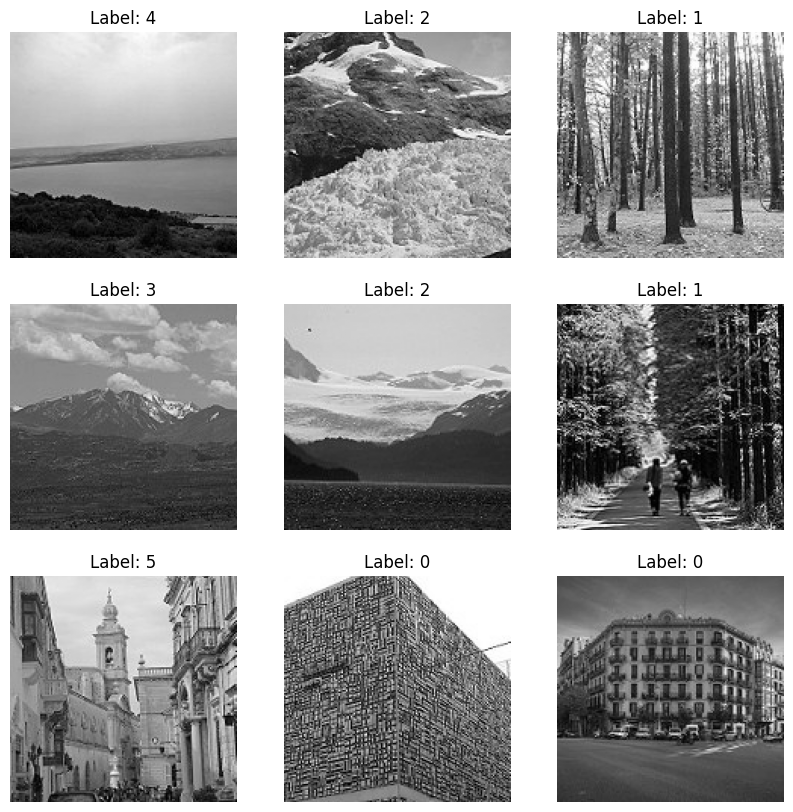

In [7]:
# Check some examples
for images, labels in train_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

## Preparing Validation and Test Datasets with Stratified Sampling

In this section, we load the validation dataset, apply stratified sampling to ensure class balance, and create separate **validation** and **test** datasets.

### **Steps:**

1. **Load the Full Validation Dataset**:  
   - The dataset is located at `'/kaggle/input/intel-image-classification/seg_test/seg_test'`.
   - `datasets.ImageFolder(root=val_path, transform=transform)` loads the dataset and applies the same transformations used for training.
   - `val_dataset_full.targets` contains the class labels, which are converted into a NumPy array for stratified sampling.

2. **Perform Stratified Sampling**:  
   - `StratifiedShuffleSplit(n_splits=num_iterations, test_size=sample_size, random_state=42)` ensures that each subset maintains the same class distribution as the full dataset.
   - `num_iterations=2` creates two non-overlapping samples: one for **validation** and one for **testing**.
   - The loop iterates through the splits and extracts indices for the validation and test subsets.

3. **Assign the Samples to Validation and Test Sets**:  
   - The first sample (`sample_datasets[0]`) is used as the **validation dataset**.
   - The second sample (`sample_datasets[1]`) is used as the **test dataset**.

4. **Create DataLoaders**:  
   - The `DataLoader` is used to efficiently load data in batches.
   - A batch size of `100` is set.
   - `shuffle=False` ensures that the order remains consistent, preserving the stratified class distribution.

### **Purpose of This Approach**:
- Stratified sampling ensures that both validation and test datasets **maintain the original class distribution**, avoiding potential class imbalance issues.
- The validation dataset helps fine-tune the model, while the test dataset provides a final unbiased evaluation.

This setup ensures a fair and balanced model assessment before deploying it on unseen competition data.

In [8]:
#Validation and test data
val_path = '/kaggle/input/intel-image-classification/seg_test/seg_test'
val_dataset_full = test_dataset#Dataset for the seg_test path

targets = val_dataset_full.labels.to_numpy()
sample_size = 100

splitter = StratifiedShuffleSplit(
    n_splits=2,
    test_size=sample_size,
    random_state=42
)

sample_datasets = []
for train_idx, sample_idx in splitter.split(np.zeros(len(targets)), targets):
    sample_datasets.append(Subset(val_dataset_full, sample_idx))

val_dataset = sample_datasets[0]
test_dataset = sample_datasets[1]

# Define batch size
batch_size = 100
# Create DataLoaders
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


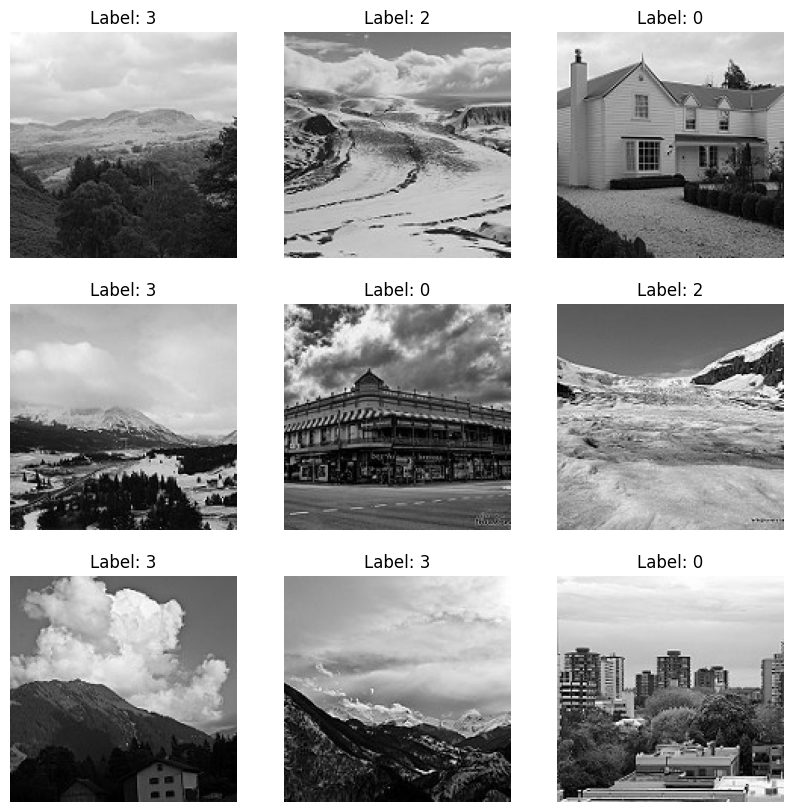

In [9]:
# Check some examples of the validation data
for images, labels in val_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

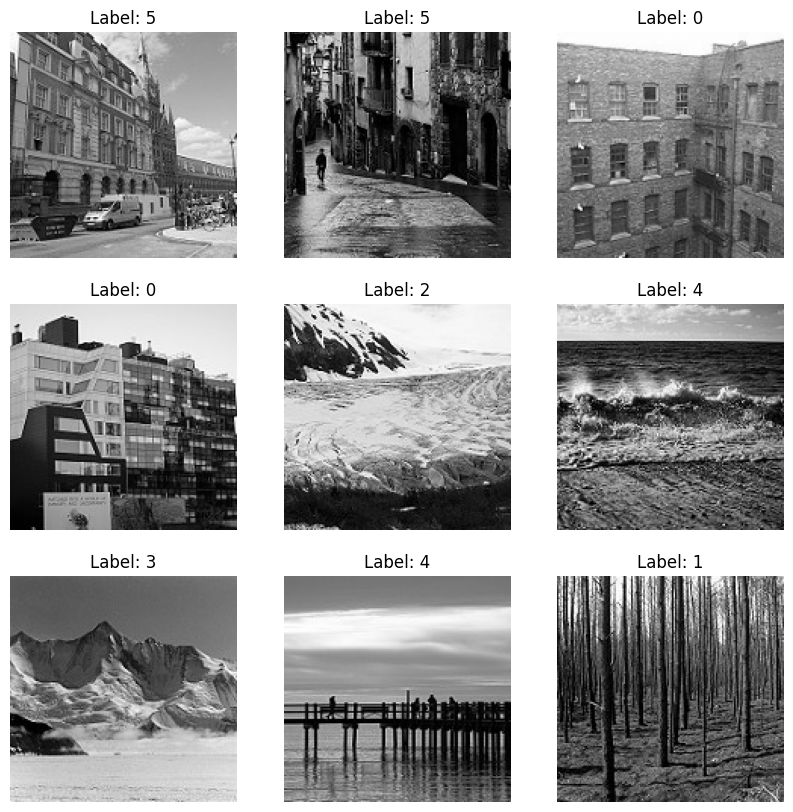

In [10]:
# Check some examples of the test data
for images, labels in test_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

## Preparing the Competition Test Dataset

This section creates a dataset for the **competition test data** (`comp_test`), which consists of **unlabeled images**. The goal is to prepare these images for inference so that participants can generate predictions.

### **Steps:**

1. **List Image Files in the Directory**:  
   - The directory `'/kaggle/input/intel-image-classification/seg_pred/seg_pred'` contains the competition test images.
   - `os.listdir(image_directory)` retrieves all filenames from the directory.
   - The list is **filtered** to include only valid image file formats (`.png`, `.jpg`, `.jpeg`, `.gif`, `.bmp`).

2. **Select a Subset of Images**:  
   - The first `200` images are selected for inference using `image_files[:200]`.  
   - This ensures a manageable dataset size for predictions.

3. **Define a Custom Dataset (`SelectedFilesDataset`)**:  
   - A PyTorch `Dataset` is created to handle only the selected images.
   - It takes the **root directory** and **list of filenames** as inputs.
   - In `__getitem__`, it loads each image using `PIL.Image.open()` and converts it to **RGB** format.
   - If transformations (`transform`) are provided, they are applied before returning the image and its filename.

4. **Create the DataLoader**:  
   - `DataLoader(comp_test_dataset, batch_size=100, shuffle=False)` efficiently loads i


In [11]:
# Step 1: List the images in the directory
image_directory = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred'
image_files = os.listdir(image_directory)

# Filter out only files with image extensions if necessary
image_files = [f for f in image_files if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

# Step 2: Select the first 200 images
image_files = image_files[:200]

class SelectedFilesDataset(Dataset):
    def __init__(self, root_dir, file_names, transform=None):
        """
        Args:
            root_dir (str): Directory where files are stored.
            file_names (list): List of selected filenames (not full paths).
            transform (callable, optional): Transformations to apply to images.
        """
        self.root_dir = root_dir
        self.file_names = file_names
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(file_path).convert("RGB")  # Load image

        if self.transform:
            image = self.transform(image)

        return image, self.file_names[idx]  # Return image + filename

# Example usage

comp_test_dataset = SelectedFilesDataset(image_directory, image_files, transform = transform)
comp_test_loader = DataLoader(comp_test_dataset, batch_size=100, shuffle=False)

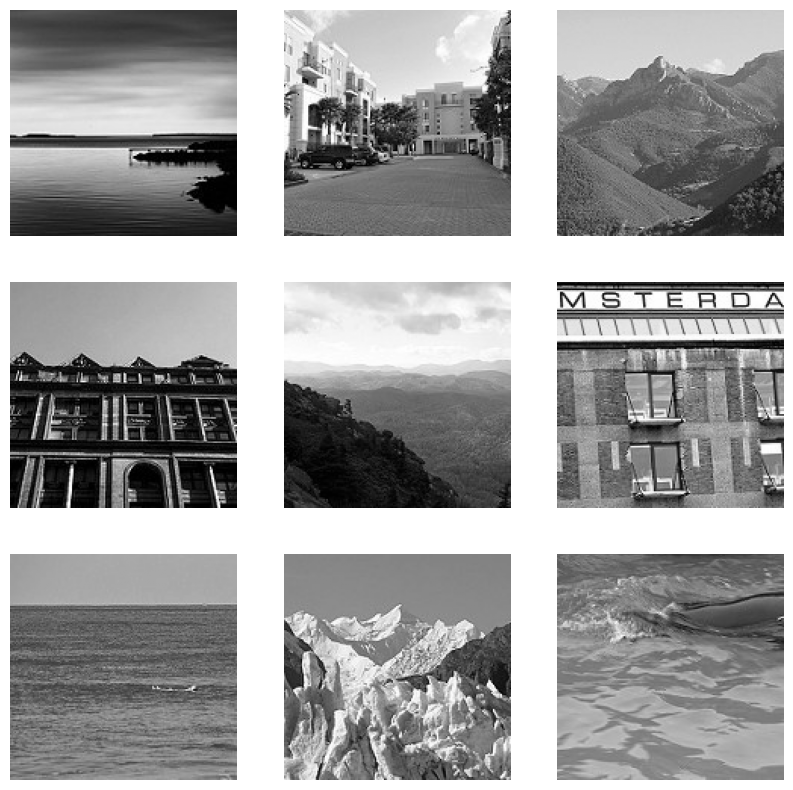

In [12]:
# Check some examples of the competition test data
for images, labels in comp_test_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        #plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

## **Step 2: Model Training Setup**

This step focuses on defining the **deep learning model**, setting up the **loss function**, **optimizer**, and establishing the **training loop**.

### **Define the Model Architecture**
A simple feed forward deep learning model is created for image classification. The architecture should be appropriate for the dataset, considering its complexity and number of classes.


In [13]:
# Check if CUDA is available and set the device accordingly
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'

# Define the number of input features and output classes
num_features = 22500
num_classes = 6

# Initialize the network and loss function

### **2. Define the Loss Function and Optimizer**
- The **loss function** (e.g., `CrossEntropyLoss`) measures how well the model's predictions match the true labels.
- The **optimizer** (e.g.,`SGD`) updates the model’s parameters to minimize the loss.

In [14]:
class PyTorchMLP(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()

        self.all_layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_features, 1024),
            torch.nn.ReLU(),
            # 2nd hidden layer
            torch.nn.Linear(1024, 512),
            torch.nn.ReLU(),
            # 3 hidden layer
            torch.nn.Linear(512, 128),
            torch.nn.ReLU(),
            # output layer
            torch.nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        logits = self.all_layers(x)
        return logits

### **3. Training Loop**
The model is trained iteratively using:
1. **Forward pass** – The model makes predictions.
2. **Loss computation** – The difference between predictions and actual labels is calculated.
3. **Backward pass** – Gradients are computed via backpropagation.
4. **Parameter update** – The optimizer updates model weights to minimize loss.
5. **Evaluation on the validation set** – The model’s performance is monitored to avoid overfitting.

In [15]:
def compute_accuracy(model, dataloader):

    model = model.eval()

    correct = 0.0
    total_examples = 0

    for idx, (features, labels) in enumerate(dataloader):

        with torch.no_grad():
            logits = model(features.to(device))

        predictions = torch.argmax(logits, dim=1)

        compare = labels.to(device) == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)

    return correct / total_examples

In [16]:
import torch.nn.functional as F

torch.manual_seed(1)
model = PyTorchMLP(num_features, num_classes)
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

num_epochs = 10

loss_list = []
train_acc_list, val_acc_list = [], []
for epoch in range(num_epochs):

    model = model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):

        logits = model(features.to(device))

        loss = F.cross_entropy(logits, labels.to(device))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if not batch_idx % 250:  # LOGGING
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Train Loss: {loss:.2f}"
            )

        loss_list.append(loss.item())


Epoch: 001/010 | Batch 000/439 | Train Loss: 1.79
Epoch: 001/010 | Batch 250/439 | Train Loss: 1.51
Epoch: 002/010 | Batch 000/439 | Train Loss: 1.44
Epoch: 002/010 | Batch 250/439 | Train Loss: 1.40
Epoch: 003/010 | Batch 000/439 | Train Loss: 1.17
Epoch: 003/010 | Batch 250/439 | Train Loss: 1.45
Epoch: 004/010 | Batch 000/439 | Train Loss: 1.01
Epoch: 004/010 | Batch 250/439 | Train Loss: 1.03
Epoch: 005/010 | Batch 000/439 | Train Loss: 0.82
Epoch: 005/010 | Batch 250/439 | Train Loss: 1.34
Epoch: 006/010 | Batch 000/439 | Train Loss: 0.81
Epoch: 006/010 | Batch 250/439 | Train Loss: 1.04
Epoch: 007/010 | Batch 000/439 | Train Loss: 0.44
Epoch: 007/010 | Batch 250/439 | Train Loss: 0.92
Epoch: 008/010 | Batch 000/439 | Train Loss: 0.82
Epoch: 008/010 | Batch 250/439 | Train Loss: 0.63
Epoch: 009/010 | Batch 000/439 | Train Loss: 0.80
Epoch: 009/010 | Batch 250/439 | Train Loss: 0.55
Epoch: 010/010 | Batch 000/439 | Train Loss: 0.55
Epoch: 010/010 | Batch 250/439 | Train Loss: 0.41


### **4. Model Evaluation on Test Set**

After training, the model's performance is assessed on the test dataset to evaluate its generalization to unseen data. This involves computing the loss and accuracy without updating model parameters, ensuring an unbiased estimate of its predictive capabilities.

In [17]:
train_acc = compute_accuracy(model, train_loader)
val_acc = compute_accuracy(model, val_loader)
test_acc = compute_accuracy(model, test_loader)

print(f"Train Acc {train_acc*100:.2f}%")
print(f"Val Acc {val_acc*100:.2f}%")
print(f"Test Acc {test_acc*100:.2f}%")

Train Acc 79.21%
Val Acc 47.00%
Test Acc 47.00%


### **5. Generating Predictions for the Competition Test Set**

After training and validating the model, the next step is to generate predictions for the comp_test dataset, which contains unlabeled data. This involves processing the dataset through the trained model to obtain predicted labels. These predictions are then formatted according to the competition's submission requirements, a CSV file with each image's filename and its corresponding predicted label. This submission file is then uploaded to the competition platform for evaluation against the hidden ground-truth labels.

In [18]:
preds = []
ids = []

model.eval() 

with torch.no_grad():
    for images, names in comp_test_loader:

        X = images.view(images.shape[0], -1).to(device)

        # Forward pass
        Z = model(X)
        _, predicted = torch.max(Z, 1)

        preds.extend(predicted.cpu().numpy())
        ids.extend(names)

In [19]:
import pandas as pd 

df = pd.DataFrame({
    'id': ids,
    'pred': preds
})

df.to_csv('predictions.csv', index=False)

print("CSV listo")


CSV listo
